In [36]:
import xarray as xr, matplotlib, matplotlib.pyplot as plt, pandas as pd, geopandas as gpd, numpy as np
import sys; sys.path.append('../../wwa'); from taylorDiagram import TaylorDiagram, taylor_scores
from IPython.display import clear_output
matplotlib.rcParams['savefig.bbox'] = "tight"

# Download data from Climate Explorer

In [ ]:
! wget https://climexp.knmi.nl/data/igiss_al_gl_a_4yrlo.dat -O data/gmst.dat
clear_output(wait = False)

In [2]:
! wget https://climexp.knmi.nl/dyn_links/era5_msl_daily_extended_-100--60E_30-65N_-999-lastyear.nc -O data/era5_msl_daily_extended_-100--60E_30-65N.nc
clear_output(wait = False)

--2026-02-26 15:06:42--  https://climexp.knmi.nl/dyn_links/era5_msl_daily_extended_-100--60E_30-65N_-999-lastyear.nc
Resolving climexp.knmi.nl (climexp.knmi.nl)... 2a0c:5bc0:4c:ff::9126:ce95, 145.38.206.149
Connecting to climexp.knmi.nl (climexp.knmi.nl)|2a0c:5bc0:4c:ff::9126:ce95|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 458384359 (437M) [application/x-netcdf]
Saving to: ‘era5_msl_daily_extended_-100--60E_30-65N.nc’

era5_msl_daily_exte 100%[===================>] 437.15M  49.8MB/s    in 11s     

2026-02-26 15:06:54 (38.9 MB/s) - ‘era5_msl_daily_extended_-100--60E_30-65N.nc’ saved [458384359/458384359]



# Analogues

## Functions

In [15]:
def euclidean_distance(da, ev_date):
    
    # apply area-weighting
    weights = np.cos(np.deg2rad(da.lat))
    da_weighted = np.multiply(da, weights)

    # remove spatial mean from each day
    da_weighted = da_weighted - da_weighted.mean(["lat", "lon"])

    # squared differences
    sqdiff = np.square(da_weighted - da_weighted.sel(time = ev_date))

    # spatial sum & sqrt
    ed = np.sqrt(sqdiff.sum(["lat", "lon"])).rename("euclidean_dist")

    return ed

In [33]:
# needs to be generalised to accept any time series & analogue field, and to manually adjust the xlim
def tplot(field, ts, d, cmap, max_sd = None, rms_quantiles = None):
    edist = euclidean_distance(field, d)
    corrs = xr.corr(field.sel(time = d),field, ["lat", "lon"])
    sds = field.std(["lat", "lon"])
    
    # and the colours for plotting
    ts_n = ts / ts.max()
    
    # set xlims
    ref_sd = sds.sel(time = d).values
    if not max_sd: 
        max_sd = np.ceil(sds.max().values / ref_sd)
    else:
        max_sd = max_sd / ref_sd
    
    # make Taylor diagram
    fig = plt.figure(figsize = (12,6), dpi= 100, facecolor='w', edgecolor='k')
    td = TaylorDiagram(ref_sd, fig = fig, rect = 111, label = d, srange = (0, max_sd), extend = True)
    
    td.add_contours(colors = "mistyrose", zorder = -9) # lines of equal RMSE
    td.add_grid(color = "papayawhip", zorder = -9)  # lines of equal correlation & SD

    if not (not rms_quantiles):
        rms = np.sqrt(ref_sd**2 + sds**2 - 2*ref_sd*sds*corrs)
        td.add_contours(colors = "darkred", levels = rms.quantile(rms_quantiles), zorder = 999, linewidths = 0.5)
    
    # much slower but allows for different colour per point
    for i in range(len(edist)):
        # if not (edist.time.dt.month[i]).isin([12,1,2]): continue
        td.add_sample(sds.values[i], corrs.values[i], color = cmap(ts_n[i]), alpha = 0.95, marker = ".", ms = 7, ls = '', zorder = ts_n[i])

## Check analogue distances

In [27]:
mslp = xr.open_dataset("data/era5_msl_daily_extended_-100--60E_30-65N.nc").msl
ts = pd.read_csv("data/prsn_impact_daily_ts_ERA5-Land.csv", index_col = "time", parse_dates = ["time"]).to_xarray().prsn + 273.15

# filter to just the months of interest
ts = ts.sel(time = ts.time.dt.month.isin([12,1,2]))
mslp = mslp.sel(time = ts.time)

d = "2026-01-26"

0.0 1800.0001


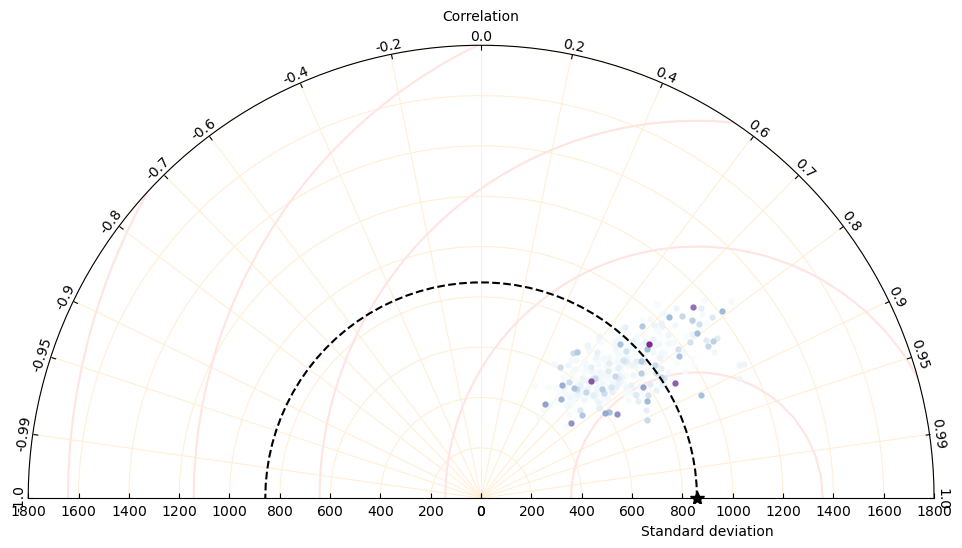

In [34]:
edist = euclidean_distance(mslp, d)

edist_q05 = edist.where(edist <= edist.quantile(0.05), drop = True)

tplot(field = mslp.sel(time = edist_q05.time), ts = ts.sel(time = edist_q05.time), d = d, cmap = matplotlib.colormaps["BuPu"], max_sd = 1800)

0.0 1800.0001
0.0 1800.0001


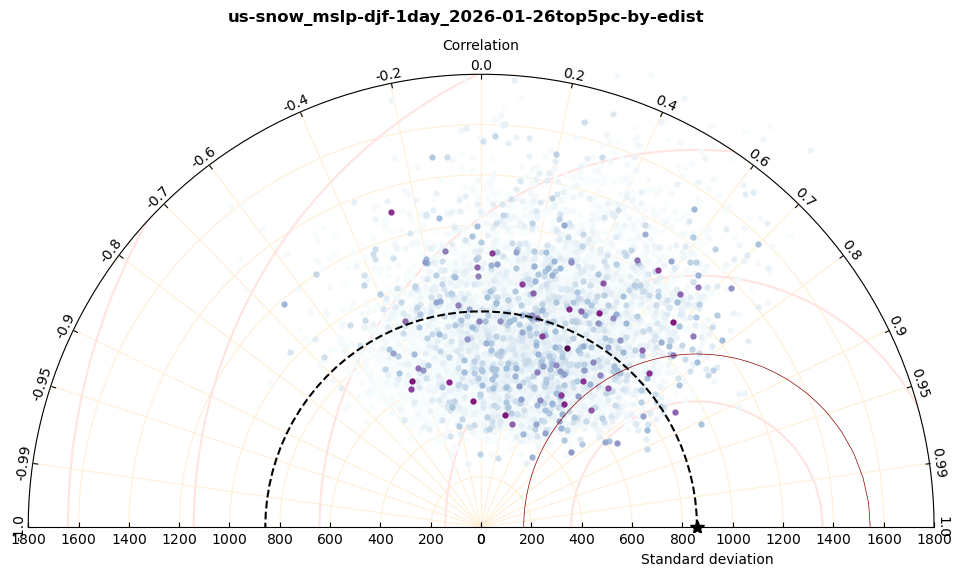

In [35]:

fnm_root = "us-snow_mslp-djf-1day_"+d+"top5pc-by-edist"

tplot(field = mslp, ts = ts, d = d, cmap = matplotlib.colormaps["BuPu"], max_sd = 1800, rms_quantiles = [0.05])
plt.suptitle(fnm_root, fontweight = "bold")
plt.savefig("fig/"+fnm_root)

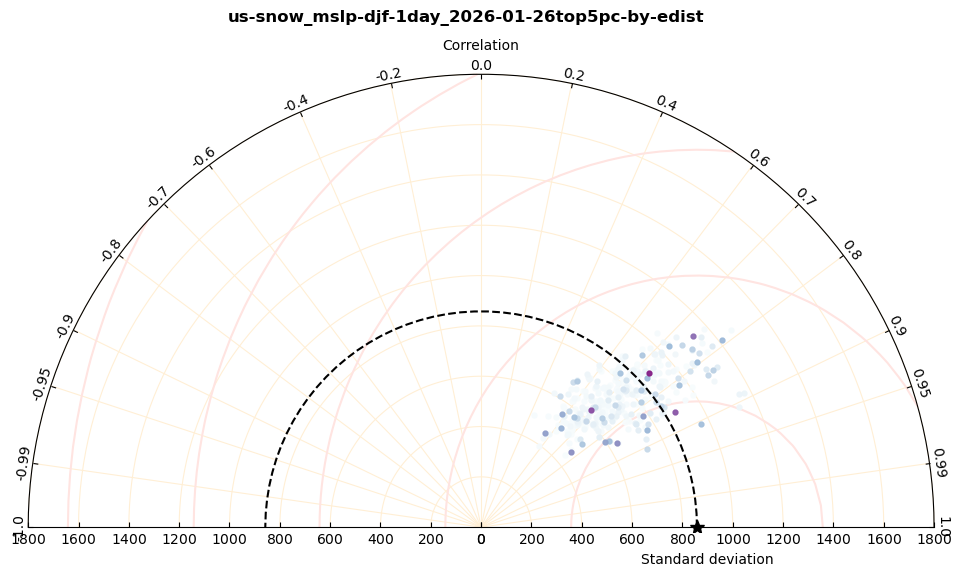

In [54]:
d = "2026-01-26"
fnm_root = "us-snow_mslp-djf-1day_"+d+"top5pc-by-edist"

tplot(field = mslp.sel(time = edist_q05.time), ts = ts.sel(time = edist_q05.time), d = d, cmap = matplotlib.colormaps["BuPu"], max_sd = 1800)
plt.suptitle(fnm_root, fontweight = "bold")
plt.savefig("fig/"+fnm_root)

# Freezing wet days

In [56]:
region = "impact"

df = pd.merge(pd.read_csv("data/pr_"+region+"_daily_ts_ERA5-Land.csv", index_col = "time", parse_dates = ["time"]),
              pd.read_csv("data/tasmax_"+region+"_daily_ts_ERA5-Land.csv", index_col = "time", parse_dates = ["time"]),
              left_index = True, right_index = True)
df["pr"] = (df.pr + 273.15) * 86400
df["freezing"] = df.tasmax < 0
df["fwet"] = (df.pr > 0) & (df.tasmax < 0)

In [88]:
df_fdays = df.loc[df.index.month.isin([12,1,2]), ["freezing", "fwet"]].resample("YE-MAR").sum().loc[slice("1951","2025")]

<Axes: xlabel='time'>

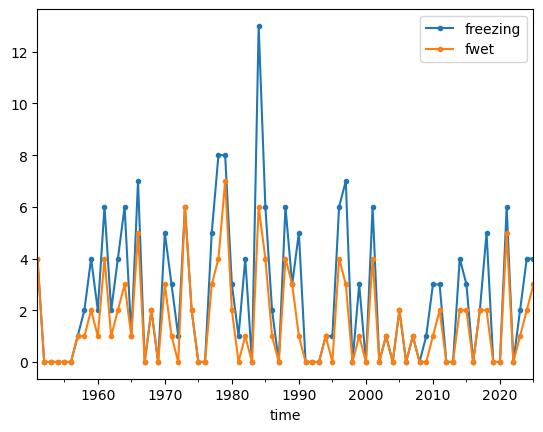

In [91]:
df_fdays.plot(marker = ".")